### Introduction: CFPB Consumer Complaint Database

#### Purpose and Scope

The **Consumer Financial Protection Bureau (CFPB)** maintains a public database of complaints submitted by consumers regarding financial products and services. Its primary purpose is to provide transparency into the marketplace, allow regulators and researchers to detect systemic issues, and ensure financial institutions respond to consumer grievances in a timely manner.

Complaints are published after companies respond or after 15 days, provided a commercial relationship is confirmed.

#### Complaint Categories and Available Fields

The dataset contains structured tabular metadata combined with unstructured text fields. Key metadata fields include:

* **Product & Sub-product:** Broad and specific financial product classifications (e.g., *Credit reporting*, *Mortgage*, *Debt collection*, *Student loans*).

* **Issue & Sub-issue:** Categorical labels detailing the specific problem (e.g., *Incorrect information on your report*, *Trouble during payment process*).

* **Company Information:** The targeted financial institution and whether their response was timely.

* **Geographic & Temporal Data:** `State`, `ZIP code`, and `Date received`.

* **Consumer Consent & Relational Status:** Flags indicating whether consent was provided to publish the written narrative publicly.

#### The Role of Complaint Narratives in NLP

The `Consumer complaint narrative` field represents raw, unstructured text written by consumers describing their experiences in their own words. Because structured categories (`Product`/`Issue`) are selected via fixed dropdowns, they don't always capture nuances or emerging pain points.

Using Natural Language Processing (NLP) on these narratives allows us to:

* Extract topics and semantic clusters beyond pre-defined categories.
* Build automated text classification models to route or tag complaints.
* Identify recurring patterns, systemic fraud, or sudden policy shifts in real time.
* Perform sentiment and emotion analysis to gauge consumer frustration levels and top     keywords they used from their narrative complaints.


#### Project Focus: 2025 Complaints

While the full CFPB dataset dates back to 2011 and contains millions of records, this notebook focuses specifically on **complaints filed during the calendar year 2025** to perform sentiment and emotion analysis to gauge consumer frustration levels and top     keywords they used from their narrative complaints..

#### Resources & Documentation

* **CFPB Search Interface & Data Source:** [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/)
* **Technical API & Field Definitions:** [CFPB API & Data Reference Dictionary](https://cfpb.github.io/api/ccdb/api.html)

#### Load all requirements

In [20]:
#check python version
!python3 --version

Python 3.11.1


In [21]:
# !pip install pandas numpy
# !pip install -U spacy
# !pip install -U streamlit
# !pip install -U plotly
# !pip install -U matplotlib
# !pip install -U vaderSentiment
# !pip install -U textblob
# !pip install -U wordcloud
# !pip install -U scikit-learn
# !pip install -U sentence-transformers
#!pip install -U bertopic
# !pip install -U transformers
# !pip install -U torch
#!pip install vaderSentiment
!pip install wordcloud tqdm

In [22]:
import pandas as pd
import argparse
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from spacy.matcher import PhraseMatcher
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter

#### Loading 2025 complaints dataset 

In [23]:
#load csv data into a pandas DataFrame
df = pd.read_csv("../../data/complaints_in_just_2025.csv",
                 low_memory=False).dropna(subset=['Consumer complaint narrative'])

In [24]:
df.shape

(1221970, 16)

In [25]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
1,2025-04-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal c...",NaN,MOHELA,NE,681XX,NaN,Web,2025-04-08,Closed with explanation,No,12856469
2,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",Struggling with a XXXX has significantly impac...,NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708
3,2025-04-18,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,I have taken out parent loans on behalf of my ...,NaN,MOHELA,OH,43110,Servicemember,Web,2025-04-18,Closed with explanation,No,13062648
6,2025-05-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,On my XXXX credit report it has my student lo...,NaN,MOHELA,CO,80020,NaN,Web,2025-05-21,Closed with explanation,No,13618226
7,2025-05-29,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I XXXX XXXX am writing to tell you about whats...,NaN,MOHELA,MI,48228,Servicemember,Web,2025-05-29,Closed with explanation,No,13768659


In [26]:
df.groupby('Product').size().reset_index(name='count').sort_values(
    by='count', ascending=False)

,Product,count
2,Credit reporting or other personal consumer re...,912758
3,Debt collection,100600
5,"Money transfer, virtual currency, or money ser...",64832
0,Checking or savings account,51447
1,Credit card,41494
6,Mortgage,14015
10,Vehicle loan or lease,11680
9,Student loan,10881
7,"Payday loan, title loan, personal loan, or adv...",7800
8,Prepaid card,3822


In [27]:
df.groupby([
    'Product',
    'Sub-product'
]).size().reset_index(name='count').sort_values(by='count', ascending=False)

# Count complaints for each product and sub-product combination.
# Calculate each combination's percentage of all complaints, sort by count, and keep the top 10.
product_counts = (
    df.groupby(['Product', 'Sub-product'])
      .size()
      .reset_index(name='count')
)
product_counts['percentage'] = (
    product_counts['count'] / product_counts['count'].sum() * 100
).round(2)
product_counts.sort_values(by='count', ascending=False).head(10)

,Product,Sub-product,count,percentage
6,Credit reporting or other personal consumer re...,Credit reporting,906811,74.21
24,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,47992,3.93
1,Checking or savings account,Checking account,43209,3.54
11,Debt collection,I do not know,41556,3.40
4,Credit card,General-purpose credit card or charge card,36048,2.95
9,Debt collection,Credit card debt,17974,1.47
14,Debt collection,Other debt,16872,1.38
27,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,10748,0.88
54,Vehicle loan or lease,Loan,10107,0.83
51,Student loan,Federal student loan servicing,8904,0.73


In [28]:
# The 2025 dataset has 5,443,005 rows and 16 columns
# The full dataset has 15,896,496 observations
df.shape

(1221970, 16)

In [29]:
# List the raw data types of all columns of the Pandas data frame
df.dtypes

Date received                     str
Product                           str
Sub-product                       str
Issue                             str
Sub-issue                         str
Consumer complaint narrative      str
Company public response           str
Company                           str
State                             str
ZIP code                          str
Tags                              str
Submitted via                     str
Date sent to company              str
Company response to consumer      str
Timely response?                  str
Complaint ID                    int64
dtype: object

In [30]:
# Convert date columns to datetime and normalize timestamps to midnight (YYYY-MM-DD).
# pd.to_datetime handles both string and already-converted datetime values.
df['Date received'] = pd.to_datetime(
    df['Date received'], errors='coerce').dt.normalize()

df['Date sent to company'] = pd.to_datetime(
    df['Date sent to company'], errors='coerce').dt.normalize()

In [31]:
# Look at a few obs to make sure we have correctly formatformatted date and time.
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
1,2025-04-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal c...",NaN,MOHELA,NE,681XX,NaN,Web,2025-04-08,Closed with explanation,No,12856469
2,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",Struggling with a XXXX has significantly impac...,NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708
3,2025-04-18,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,I have taken out parent loans on behalf of my ...,NaN,MOHELA,OH,43110,Servicemember,Web,2025-04-18,Closed with explanation,No,13062648
6,2025-05-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,On my XXXX credit report it has my student lo...,NaN,MOHELA,CO,80020,NaN,Web,2025-05-21,Closed with explanation,No,13618226
7,2025-05-29,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I XXXX XXXX am writing to tell you about whats...,NaN,MOHELA,MI,48228,Servicemember,Web,2025-05-29,Closed with explanation,No,13768659


In [32]:
# Group complaints by year received and count observations
df.groupby(df['Date received'].dt.year).size()

Date received
2025    1221970
dtype: int64

In [33]:
# Group complaints by product category and count observations
df.groupby(df['Product']).size()

Product
Checking or savings account                                 51447
Credit card                                                 41494
Credit reporting or other personal consumer reports        912758
Debt collection                                            100600
Debt or credit management                                    2641
Money transfer, virtual currency, or money service          64832
Mortgage                                                    14015
Payday loan, title loan, personal loan, or advance loan      7800
Prepaid card                                                 3822
Student loan                                                10881
Vehicle loan or lease                                       11680
dtype: int64

In [34]:
# Group complaints by issue category and count observations

df.groupby(df['Issue']).size()

Issue
Advertising                                                       59
Advertising and marketing, including promotional offers         1987
Applying for a mortgage or refinancing an existing mortgage     1527
Attempts to collect debt not owed                              45773
Can't contact lender or servicer                                 134
                                                               ...  
Vehicle was repossessed or sold the vehicle                      105
Was approved for a loan, but didn't receive money                 15
Was approved for a loan, but didn't receive the money             75
Written notification about debt                                24189
Wrong amount charged or received                                 284
Length: 89, dtype: int64

In [35]:
# Group by the company public response and count obsevations

df.groupby(df['Company public response']).size()

Company public response
Company believes complaint caused principally by actions of third party outside the control or direction of the company       297
Company believes complaint is the result of an isolated error                                                                 215
Company believes complaint relates to a discontinued policy or procedure                                                        4
Company believes complaint represents an opportunity for improvement to better serve consumers                                334
Company believes it acted appropriately as authorized by contract or law                                                    23150
Company believes the complaint is the result of a misunderstanding                                                            318
Company believes the complaint provided an opportunity to answer consumer's questions                                         954
Company can't verify or dispute the facts in the complaint        

In [36]:
# Group by company response to consumer and count obsevations

df.groupby(df['Company response to consumer']).size()

Company response to consumer
Closed with explanation            768024
Closed with monetary relief         15145
Closed with non-monetary relief    434484
In progress                           116
Untimely response                    4201
dtype: int64

In [37]:
# Group by timely response and Company response to consumer to consumer complaints and count obsevations

df.groupby(['Timely response?','Company response to consumer']).size()

Timely response?  Company response to consumer   
No                Closed with explanation              6063
                  Closed with monetary relief            78
                  Closed with non-monetary relief       325
                  Untimely response                    4201
Yes               Closed with explanation            761961
                  Closed with monetary relief         15067
                  Closed with non-monetary relief    434159
                  In progress                           116
dtype: int64

In [38]:
# Count up the number of unique companies having consumer complaints

df['Company'].nunique()

3224

In [39]:
# Find the top 10 companies with the most consumer complaints
df['Company'].value_counts().head(10)

Company
EQUIFAX, INC.                             315504
TRANSUNION INTERMEDIATE HOLDINGS, INC.    294058
Experian Information Solutions Inc.       268568
Block, Inc.                                38103
Early Warning Services, LLC                17665
CAPITAL ONE FINANCIAL CORPORATION          17160
JPMORGAN CHASE & CO.                       11795
NAVY FEDERAL CREDIT UNION                  10624
CITIBANK, N.A.                              9160
WELLS FARGO & COMPANY                       9047
Name: count, dtype: int64

### Summary of the data wrangling

**Dataset loading and validation:** Import the required Python libraries and loads the 2025 CFPB complaint file into a pandas DataFrame. Rows without a `Consumer complaint narrative` are removed.

### Key insights

**Credit reporting dominates the dataset.** Credit reporting or other personal consumer reporting complaints account for the largest product category and substantially exceed the other categories. This concentration should be considered when interpreting NLP results because overall themes may primarily reflect credit-reporting experiences.

**Debt collection and money-transfer complaints are also prominent.** These categories form important secondary groups and may reveal distinct issues involving collection practices, payment transfers, and account access.

**Complaint narratives are a valuable source of unstructured information.** Product and issue fields provide structured labels, while the narratives provide consumers' descriptions of events, impacts, and desired resolutions. This supports text classification, topic discovery, and sentiment or outcome analysis.

**Company-response fields enable outcome analysis.** Comparing `Company response to consumer` with `Timely response?` can show whether timely handling is associated with different resolution outcomes. These fields describe reported responses, not necessarily whether the consumer considered the issue fully resolved.

**Company counts may reflect market size as well as complaint frequency.** Companies with the most complaints may serve more customers or offer more products, so complaint volume should not be interpreted as a complaint rate without an appropriate exposure denominator.

**Privacy masking affects text modeling.** CFPB narratives may contain redacted names, dates, account numbers, and other identifying information. These masks should be handled during preprocessing so they do not dominate the vocabulary or create misleading NLP features.

In [40]:
df_2025 = df.copy()
df_2025.rename(
    columns={'Consumer complaint narrative': 'narrative'},
    inplace=True
)

## Data preparation
The CFPB database is massive, but not all entries contain text because consumers must explicitly opt-in to share their narratives.

Here is a step-by-step pipeline to clean, preprocess, and structure this data for Natural Language Processing (NLP).

* Filter out rows where Consumer complaint narrative is null.

* The CFPB heavily sanitizes data for privacy, replacing names, account numbers, and dates with blocks of XXXX. They hold no sentiment 
value and can confuse word embeddings. Therefore, remove them or replace them with a single space. 

In [41]:
#load modules
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [42]:
df = df.dropna(subset=['Consumer complaint narrative'])
# Rename for ease
df['narrative'] = df['Consumer complaint narrative']

df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,narrative
1,2025-04-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal c...",NaN,MOHELA,NE,681XX,NaN,Web,2025-04-08,Closed with explanation,No,12856469,"To Whom It May Concern, I am filing a formal c..."
2,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",Struggling with a XXXX has significantly impac...,NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708,Struggling with a XXXX has significantly impac...
3,2025-04-18,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,I have taken out parent loans on behalf of my ...,NaN,MOHELA,OH,43110,Servicemember,Web,2025-04-18,Closed with explanation,No,13062648,I have taken out parent loans on behalf of my ...
6,2025-05-21,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,On my XXXX credit report it has my student lo...,NaN,MOHELA,CO,80020,NaN,Web,2025-05-21,Closed with explanation,No,13618226,On my XXXX credit report it has my student lo...
7,2025-05-29,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I XXXX XXXX am writing to tell you about whats...,NaN,MOHELA,MI,48228,Servicemember,Web,2025-05-29,Closed with explanation,No,13768659,I XXXX XXXX am writing to tell you about whats...


## Text Preprocessing Pipeline

Consumer complaint narratives are unstructured text and may contain inconsistent capitalization, punctuation, web artifacts, privacy masks, and boilerplate language. Before applying machine-learning models such as TF-IDF with logistic regression or more advanced deep-learning methods, the narratives must be normalized to reduce noise and create a consistent vocabulary.

The preprocessing workflow includes the following steps:

- **Normalize privacy masks:** Standardize CFPB redactions such as `XXXX`, masked dates, and masked dollar amounts so that they are treated consistently rather than as unrelated tokens.

- **Convert text to lowercase:** Make words such as `Credit` and `credit` equivalent, reducing unnecessary vocabulary duplication.

- **Remove web artifacts:** Remove URLs, HTML entities, duplicate whitespace, and other formatting artifacts that do not contribute meaningful information.

- **Remove punctuation and special characters:** Reduce noise while preserving information that may be useful for interpretation.

- **Tokenize the narratives:** Split each narrative into individual words or tokens for analysis.

- **Remove stop words selectively:** Remove frequent words with limited analytical value, but retain negation terms such as `not` and `no` because they can change the meaning of a complaint.

- **Lemmatize words:** Reduce related word forms to a common base form; for example, `charged`, `charging`, and `charges` can be represented by `charge`.

- **Filter uninformative records:** Remove empty, whitespace-only, duplicate, or very short narratives that are unlikely to provide sufficient information for modeling.

This sequence produces cleaner text while preserving important complaint meaning and resolution-related language for downstream NLP analysis.

In [43]:
def normalize_masks(text):
    """Replace CFPB privacy redactions with meaningful standard tokens."""
    # Replace masked dates, such as XX/XXX/XXXXX, with a consistent date token.
    text = re.sub(r'\b[xX]{2}/[xX]{3}/[xX]{4\b', '[MASKED_DATE]', text)
    # Replace masked dollar amounts or numeric values with an amount token.
    text = re.sub(r'\$[xX,]+', '[MASKED_AMOUNT]', text)
    # Replace remaining sequences of two or more x/X characters with a text token.
    text = re.sub(r'[xX]{2,}', '[MASKED_TEXT]', text)
    # Apply the standardized masking function to the complaint narratives.
    text = re.sub(r'X{2,}', '[REDACTED]', text)
    return text

# Create a cleaned text column while preserving the original complaint narrative.
df_2025['cleaned_narrative'] = df_2025['narrative'].apply(normalize_masks)

In [44]:
# Filter out short, non-meaningful descriptions (under 20 words)
df_2025 = df_2025[df_2025['cleaned_narrative'].apply(lambda x: len(str(x).split()) > 20)]

In [45]:
import html

def clean_web_artifacts(text):
    text = html.unescape(text) # Converts &amp; to &
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Removes URLs
    text = re.sub(r'\s+', ' ', text).strip() # Removes duplicate whitespace/newlines
    return text

In [46]:
# Remove web and formatting artifacts from the cleaned complaint narratives.
df_2025['cleaned_narrative'] = df_2025['cleaned_narrative'].apply(clean_web_artifacts)

#### Grouping shifting categorical targets to ensure text consistency

In [47]:

product_mapping = {
    'Credit card': 'Credit Card/Prepaid',
    'Prepaid card': 'Credit Card/Prepaid',
    'Credit card or prepaid card': 'Credit Card/Prepaid',
}
df_2025['Product_Standardized'] = df_2025['Product'].replace(product_mapping)

#### Keep only rows where a commercial relationship was verified and sent to the company

In [48]:
# Keep only rows where a commercial relationship was verified and sent to the company
df_2025 = df_2025[df_2025['Submitted via'] != 'Referral'] 
df_2025 = df_2025.dropna(subset=['Company response to consumer'])

#### Prune Document Length Extremes
Extremely long documents dilate the computational matrix size (especially for deep learning embedding vectors) and dilute the actual "sentiment" signal with thousands of words of standard chronological noise.

In [49]:
# Filter by token-count percentiles
df_2025['word_count'] = df_2025['cleaned_narrative'].apply(lambda x: len(x.split()))
min_thresh = df_2025['word_count'].quantile(0.05)
max_thresh = df_2025['word_count'].quantile(0.95)

df_filtered = df_2025[(df_2025['word_count'] >= min_thresh) & (df_2025['word_count'] <= max_thresh)]

In [50]:
df_filtered.shape

(1055842, 19)

In [51]:
# Map responses to Binary Sentiment/Outcome (1 = Relief/Positive resolution, 0 = No relief)
relief_responses = ['Closed with monetary relief', 'Closed with non-monetary relief']
df_filtered['response_binary'] = df_filtered['Company response to consumer'].apply(lambda x: 1 if x in relief_responses else 0)

In [52]:
df_filtered.head()

,Date received,Product,Sub-product,Issue,Sub-issue,narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,cleaned_narrative,Product_Standardized,word_count,response_binary
1,2025-04-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal c...",NaN,MOHELA,NE,681XX,NaN,Web,2025-04-08,Closed with explanation,No,12856469,"To Whom It May Concern, I am filing a formal c...",Credit reporting or other personal consumer re...,173,0
2,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or dis...",Struggling with a XXXX has significantly impac...,NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708,Struggling with a [MASKED_TEXT] has significan...,Student loan,98,0
3,2025-04-18,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,I have taken out parent loans on behalf of my ...,NaN,MOHELA,OH,43110,Servicemember,Web,2025-04-18,Closed with explanation,No,13062648,I have taken out parent loans on behalf of my ...,Student loan,292,0
7,2025-05-29,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I XXXX XXXX am writing to tell you about whats...,NaN,MOHELA,MI,48228,Servicemember,Web,2025-05-29,Closed with explanation,No,13768659,I [MASKED_TEXT] [MASKED_TEXT] am writing to te...,Credit reporting or other personal consumer re...,356,0
10,2025-06-12,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Trouble with how payments are being handled,In XX/XX/XXXX and XX/XX/XXXX my employer made ...,NaN,MOHELA,MD,207XX,NaN,Web,2025-06-12,Closed with explanation,No,14034568,In [MASKED_TEXT]/[MASKED_TEXT]/[MASKED_TEXT] a...,Student loan,301,0


In [53]:
# save the filtered DataFrame to a new CSV file
#This is the same as df_filtered csv file
df_filtered.to_csv('../../data/complaints_2025_filtered.csv', index=False)


#### SpaCy

In [61]:
df=df_filtered.sample(10000)

In [62]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,cleaned_narrative,Product_Standardized,word_count,response_binary
535714,2025-02-05,Debt collection,I do not know,Took or threatened to take negative or legal a...,Sued you without properly notifying you of law...,Midland Credit Management claims that the coun...,NaN,ENCORE CAPITAL GROUP INC.,DE,19901,NaN,Web,2025-02-05,Closed with explanation,Yes,11950839,Midland Credit Management claims that the coun...,Debt collection,102,0
3304529,2025-08-25,Credit reporting or other personal consumer re...,Other personal consumer report,Incorrect information on your report,Public record information inaccurate,I contacted XXXX and Rent Recovery seeking ful...,NaN,Rent Recovery Solutions,GA,30314,NaN,Web,2025-08-25,Closed with explanation,Yes,15498407,I contacted [MASKED_TEXT] and Rent Recovery se...,Credit reporting or other personal consumer re...,193,0
107082,2025-01-10,Credit card,General-purpose credit card or charge card,Fees or interest,Charged too much interest,My XX/XX/XXXX statement showed interest billed...,NaN,GOLDMAN SACHS BANK USA,WA,982XX,NaN,Web,2025-01-10,Closed with explanation,Yes,11472553,My [MASKED_TEXT]/[MASKED_TEXT]/[MASKED_TEXT] s...,Credit Card/Prepaid,130,0
2892059,2025-07-30,Credit card,General-purpose credit card or charge card,Closing your account,Company closed your account,Whenever I would process a payment on my credi...,NaN,CAPITAL ONE FINANCIAL CORPORATION,TX,79930,NaN,Web,2025-07-30,Closed with non-monetary relief,Yes,14970105,Whenever I would process a payment on my credi...,Credit Card/Prepaid,118,1
1912238,2025-05-22,Student loan,Private student loan,Struggling to repay your loan,Can't temporarily delay making payments,I was given the wrong date and information on ...,Company believes it acted appropriately as aut...,SLM CORPORATION,NV,89117,NaN,Web,2025-05-22,Closed with explanation,Yes,13661404,I was given the wrong date and information on ...,Student loan,53,0


In [56]:
!python3 -m spacy download en_core_web_sm
!python3 -m spacy download en_core_web_md
!python3 -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 16.9 MB/s  0:00:00 eta 0:00:01
    yapf>='0.28' ; python_version < "3.6"
        ^

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python3 -m pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 25.3 MB/s  0:00:01m0:00:0100:01
    yapf>='0.28' ; python_version < "3.6"
        ^

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python3 -m pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 17.1 MB/s  0:00:20:00:0100:01
    yapf>='0.28' ; python_version < "3.6"
        ^

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python3 -m pip install --upgrade pip
✔ Do

## Sentiment Analysis: VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool designed for short, informal text. It assigns a compound sentiment score ranging from -1 to 1, where values closer to -1 indicate more negative sentiment and values closer to 1 indicate more positive sentiment. The score is calculated from the cleaned complaint narrative and is used to summarize the emotional tone of consumers' descriptions.

Because CFPB complaint narratives are often detailed, formal, and focused on specific financial problems, VADER scores should be interpreted as an indicator of expressed sentiment rather than a direct measure of complaint severity, customer satisfaction, or resolution success.

In [63]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    score = analyzer.polarity_scores(text)
    return score["compound"]

In [64]:
df["sentiment_vader"] = df["cleaned_narrative"].apply(vader_score)

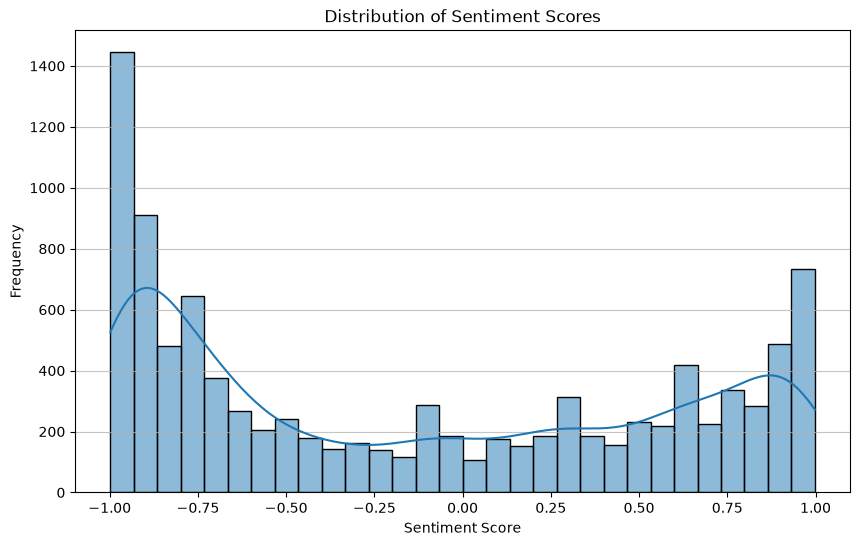

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_vader'], bins=30, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [67]:
pd.set_option('display.max_colwidth', None)

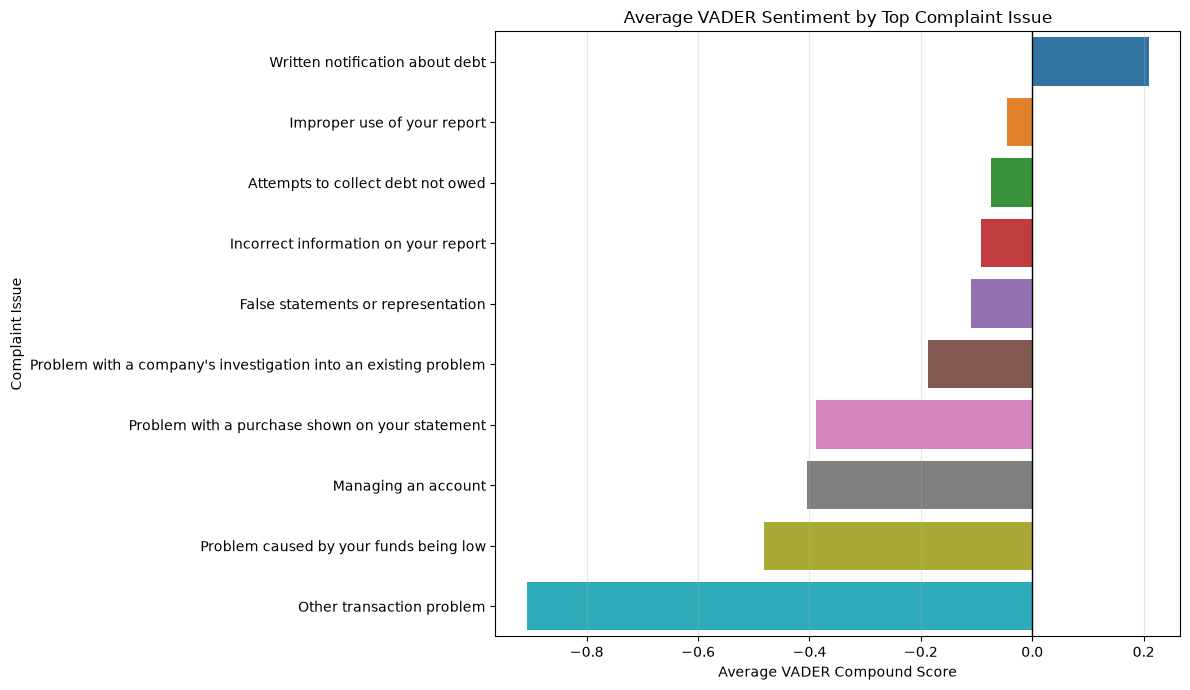

In [68]:
# Compare average VADER sentiment across the 10 most common complaint issues.
top_issues = df['Issue'].value_counts().head(10).index
issue_sentiment = (
    df[df['Issue'].isin(top_issues)]
      .groupby('Issue', as_index=False)['sentiment_vader']
      .mean()
      .sort_values('sentiment_vader', ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=issue_sentiment,
    x='sentiment_vader',
    y='Issue',
    hue='Issue',
    palette='tab10',
    legend=False
)
plt.title('Average VADER Sentiment by Top Complaint Issue')
plt.xlabel('Average VADER Compound Score')
plt.ylabel('Complaint Issue')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Interpreting the positive VADER scores

A large number of positive VADER scores does not necessarily mean that consumers were satisfied with their financial products or that their complaints were resolved positively. Several factors can explain this pattern:

- **Complaint narratives contain mixed language.** Consumers may describe a negative experience while also using positive words such as `help`, `thank`, `appreciate`, `correct`, or `resolved` when discussing a company representative, a requested outcome, or a partial improvement.

- **VADER is lexicon-based.** VADER assigns sentiment values to individual words and phrases. It may identify positive terms without fully understanding the broader financial context or the complaint's main issue.

- **Narratives often include procedural language.** Words such as `account`, `payment`, `credit`, `service`, and `information` can appear in contexts that are not emotionally positive, but the overall wording may still produce a slightly positive compound score.

- **The cleaned text changes the original writing.** Lowercasing, removing punctuation, filtering tokens, and replacing redacted information can remove emphasis, negation cues, or other context that affects sentiment scoring.

- **A positive score is not the same as a positive outcome.** VADER measures the tone expressed in the narrative; it does not measure whether the consumer received monetary relief, non-monetary relief, or a satisfactory resolution.

Therefore, VADER scores should be interpreted together with the original narrative, product and issue categories, and the company-response fields. They are most useful for comparing broad language patterns across groups rather than classifying individual complaints as resolved or unresolved.

# Financial Severity Score

In [77]:

nlp = spacy.load("en_core_web_sm")

# Define categories and keyword lists
category_lexicon = {
    # Severity Levels
    "critical": [
        "foreclosure", "eviction", "bankruptcy", "homeless", "sheriff sale",
        "lease termination", "padlock", "shelter", "lawsuit", "garnishment",
        "subpoena", "attorney general", "summons", "court order", "judgment",
        "wage attachment", "poverty", "destitute", "hardship", "suicidal"
    ],
    "high": [
        "fraud", "identity theft", "stolen funds", "scam", "unauthorized transaction",
        "account takeover", "phishing", "impersonation", "wire fraud", "forgery",
        "closed account", "repossession", "collections", "frozen account",
        "seized funds", "account lock", "charge off", "predatory lending", "harassment"
    ],
    "medium": [
        "incorrect reporting", "credit score", "dispute", "fcra", "unverified debt",
        "mixed file", "late fee", "overdraft fee", "hidden charge", "unauthorized fee",
        "interest rate increase", "billing error", "escrow shortage", "double charged"
    ],

    # Domain / Action Types
    "legal_risk": [
        "lawsuit", "attorney", "lawyer", "court", "subpoena", "legal action",
        "suing", "fcra violation", "fdcpa", "tcpa", "regulatory complaint"
    ],
    "financial_loss": [
        "stolen funds", "overdraft fee", "unauthorized charge", "drained account",
        "wire fraud", "double charged", "seized funds", "unauthorized fee"
    ],
    "credit_damage": [
        "credit score dropped", "incorrect reporting", "derogatory mark",
        "late payment reported", "identity theft", "mixed file", "unverified debt"
    ]
}


# Severity Score Function

In [78]:
# Initialize matcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

# Register each category into the matcher
for cat_name, terms in category_lexicon.items():
    patterns = [nlp.make_doc(text) for text in terms]
    matcher.add(cat_name, patterns)

In [80]:
def score_multi_category(doc):
    """
    Evaluates a spaCy Doc against registered categories and returns
    counts and calculated severity metrics.
    """
    matches = matcher(doc)

    # Track term hits per category
    cat_counts = {cat: 0 for cat in category_lexicon.keys()}

    for match_id, start, end in matches:
        string_id = nlp.vocab.strings[match_id]  # Category name
        cat_counts[string_id] += 1

    # Calculate Weighted Composite Severity Score
    # Critical = 5 pts | High = 3 pts | Medium = 1 pt
    composite_severity = (
        (cat_counts['critical'] * 5) +
        (cat_counts['high'] * 3) +
        (cat_counts['medium'] * 1)
    )

    # Return dictionary of all scores
    return {
        'count_critical': cat_counts['critical'],
        'count_high': cat_counts['high'],
        'count_medium': cat_counts['medium'],
        'count_legal_risk': cat_counts['legal_risk'],
        'count_financial_loss': cat_counts['financial_loss'],
        'count_credit_damage': cat_counts['credit_damage'],
        'composite_severity_score': composite_severity
    }

# Batch process narratives
# Ensure 'cleaned_narrative' column contains only strings, converting any NaN to empty strings
docs = list(nlp.pipe(df['cleaned_narrative'].fillna(''), disable=["ner", "parser"]))
scores_list = [score_multi_category(doc) for doc in docs]

# Convert results into a DataFrame and combine with main data
score_df = pd.DataFrame(scores_list)
df_scored = pd.concat([df.reset_index(drop=True), score_df], axis=1)

In [82]:
#df_scored.head()

In [95]:
# Top Companies by Severity
import plotly.express as px
company_score = (
    df_scored
    .groupby("Company")
    ["composite_severity_score"]
    .mean()
    .reset_index()
    .sort_values(
    "composite_severity_score",
    ascending=False
    )
    .head(20)
    )

fig = px.bar(
    company_score,
    title="Top 20 Companies by Average Composite Severity Score",
    x="composite_severity_score",
    y="Company",
    orientation="h"
    )

fig.show()

### Plot Insight: top 20 companies by average composite severity score
The bar chart ranks the top 20 companies by average composite severity score, showing which firms receive the most severe complaint language on average. A higher score indicates that a company's complaints contain more critical, high-risk, or financially harmful terms, so the chart helps identify companies with the most severe consumer issues in the sampled 2025 complaints.


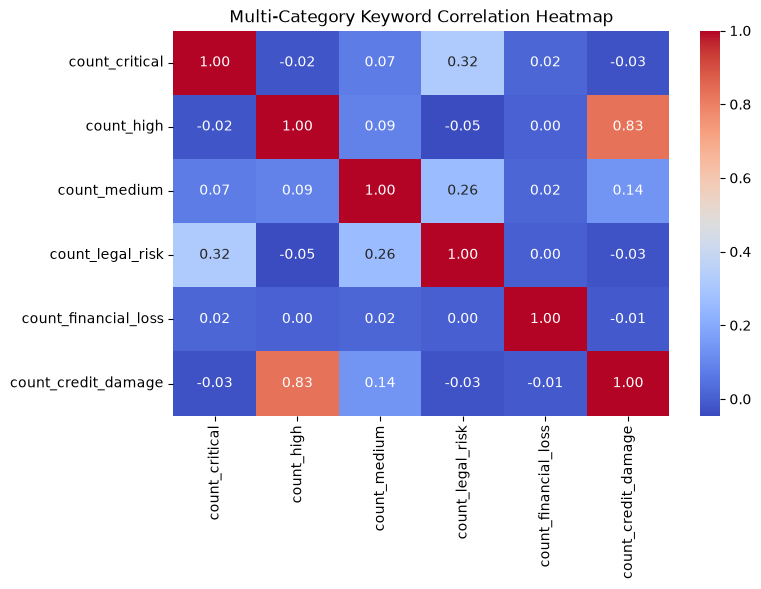

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
cat_cols = ['count_critical', 'count_high', 'count_medium', 'count_legal_risk', 'count_financial_loss', 'count_credit_damage']

sns.heatmap(df_scored[cat_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Multi-Category Keyword Correlation Heatmap')
plt.show()

/var/folders/98/wd5q4x8x321fb8d_f491fnp00000gn/T/ipykernel_25882/3382494644.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


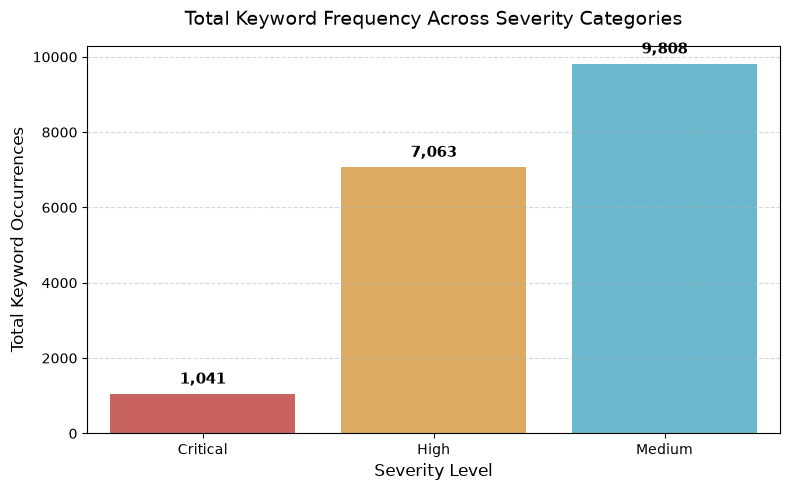

In [97]:
# Calculate total mentions for each category across the dataset
severity_totals = pd.DataFrame({
    'Severity Level': ['Critical', 'High', 'Medium'],
    'Total Mentions': [
        df_scored['count_critical'].sum(),
        df_scored['count_high'].sum(),
        df_scored['count_medium'].sum()
    ]
})

# Plot Total Mentions Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=severity_totals,
    x='Severity Level',
    y='Total Mentions',
    palette=['#d9534f', '#f0ad4e', '#5bc0de']  # Red, Orange, Blue
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

plt.title('Total Keyword Frequency Across Severity Categories', fontsize=14, pad=15)
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Total Keyword Occurrences', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [98]:

from collections import Counter

# Additional stop words specific to CFPB
custom_stopwords = {
    "bank","company","account","credit","loan","card",
    "consumer","told","said","would","could","also",
    "one","get","got","even","back","time","called",
    "call","email","letter","know","received","receive"
}

def extract_keywords(text):
    doc = nlp(str(text).lower())

    words = []

    for token in doc:

        if (
            token.is_stop
            or token.is_punct
            or token.is_space
            or token.like_num
        ):
            continue

        if token.lemma_ in custom_stopwords:
            continue

        if token.pos_ in ["NOUN", "PROPN", "ADJ"]:

            if len(token.lemma_) > 2:
                words.append(token.lemma_)

    return words

In [101]:
issue_keywords = {}

for issue, group in df_scored.groupby("Issue"):

    counter = Counter()

    for text in group["cleaned_narrative"]:

        counter.update(extract_keywords(text))

    issue_keywords[issue] = counter

for issue, counter in issue_keywords.items():

    print("\n", issue)
    print(counter.most_common(20))


 Advertising
[('vanilla', 9), ('masked_text', 8), ('website', 7), ('gift', 6), ('online', 3), ('store', 3), ('money', 3), ('applicable', 2), ('easy', 2), ('person', 2), ('message', 2), ('internet', 2), ('personal', 2), ('advertising', 2), ('order', 1), ('thing', 1), ('search', 1), ('giftcard', 1), ('purchase', 1), ('fee', 1)]

 Advertising and marketing, including promotional offers
[('masked_text', 73), ('chase', 28), ('promotional', 25), ('offer', 22), ('balance', 20), ('payment', 19), ('interest', 18), ('promotion', 16), ('month', 15), ('response', 13), ('purchase', 13), ('complaint', 12), ('statement', 11), ('bonus', 10), ('issue', 10), ('transaction', 10), ('period', 9), ('charge', 9), ('year', 9), ('additional', 8)]

 Applying for a mortgage or refinancing an existing mortgage
[('masked_text', 16), ('information', 10), ('application', 9), ('figure', 8), ('agent', 7), ('chase', 7), ('day', 6), ('notary', 6), ('property', 5), ('process', 5), ('home', 5), ('deadline', 5), ('pmi', 5

In [ ]:
from wordcloud import WordCloud

for issue, counter in issue_keywords.items():

    wc = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        colormap="tab20"
    )

    wc.generate_from_frequencies(dict(counter))

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(issue, fontsize=18)
    plt.show()

In [ ]:
rows = []

for issue, counter in issue_keywords.items():

    for word, freq in counter.most_common(20):

        rows.append({
            "Issue": issue,
            "Keyword": word,
            "Frequency": freq
        })

top20 = pd.DataFrame(rows)

top20.to_csv("Top20_Keywords_By_Issue.csv", index=False)

top20.head()